# Численное моделирование распространения сейсмических волн в двумерной среде MILEN SEM 2D. Часть третья.

## Глава II: Материал модели с разломом

### Задача

Назначить упругие свойства материала для модели с тектоническим разломом.
Исходный материал берётся из Главы I.7 (эйлерова декартова сетка 5×5 м).
Левый блок сохраняет исходный материал; правый блок — тот же материал, но смещённый
вниз на `fault_throw` (материал "приходит" из меньших глубин).

Пустоты заполняются:
- Вверху справа (0..fault_throw) — экстраполяция первого слоя
- Внизу слева (z_max..z_max+fault_throw) — экстраполяция последнего слоя

In [74]:
# Импорты
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

## Параметр угла разлома ##

In [75]:
# Угол разлома определяет суффикс входных/выходных файлов (должен совпадать с dev_3_1)
fault_angle_param = 10.0  # градусы
angle_suffix = f'_a{int(fault_angle_param)}'
print(f"Суффикс файлов: {angle_suffix}")

Суффикс файлов: _a10


## Загрузка данных ##

In [76]:
# Исходный материал на декартовой сетке 5×5 м (из Главы I.7)
orig_data = np.load('data/dev_1_7_material_grids.npz')
orig_material = orig_data['material_grid']        # (2350, 550, 3) — E, nu, rho
orig_coords = orig_data['coords_grid']            # (2350, 550, 2) — x, y
orig_layers = orig_data['layer_indexes_grid']     # (2350, 550) — номер слоя

print(f"Исходный материал: {orig_material.shape}")
print(f"Сетка: dx={orig_coords[1,0,0]-orig_coords[0,0,0]:.0f} м, "
      f"dy={orig_coords[0,1,1]-orig_coords[0,0,1]:.0f} м")
print(f"X: {orig_coords[0,0,0]:.1f} .. {orig_coords[-1,0,0]:.1f} м")
print(f"Y: {orig_coords[0,0,1]:.1f} .. {orig_coords[0,-1,1]:.1f} м")

# Геометрия с разломом (из Главы III.1)
fault_data = np.load(f'data/dev_3_1_fault_layer_boundaries{angle_suffix}.npz', allow_pickle=True)
faulted_boundaries = fault_data['layer_boundaries_array']  # (75, 1176)
distances = fault_data['distances']
fault_x = float(fault_data['fault_x'])
fault_angle = float(fault_data['fault_angle'])
fault_throw = float(fault_data['fault_throw'])
fault_indices = fault_data['fault_indices']
model_bottom_depth = float(fault_data['model_bottom_depth'])

print(f"\nПараметры разлома:")
print(f"  fault_x = {fault_x:.0f} м")
print(f"  fault_angle = {fault_angle}°")
print(f"  fault_throw = {fault_throw:.0f} м")
print(f"  model_bottom_depth = {model_bottom_depth:.0f} м")

Исходный материал: (2350, 550, 3)
Сетка: dx=5 м, dy=5 м
X: 2.5 .. 11747.5 м
Y: 2.5 .. 2747.5 м

Параметры разлома:
  fault_x = 5875 м
  fault_angle = 10.0°
  fault_throw = 50 м
  model_bottom_depth = 2800 м


## Построение новой декартовой сетки ##

Новая сетка покрывает расширенную область: глубина увеличена на `fault_throw`.
Шаг сетки остаётся 5×5 м.

In [77]:
dx, dy = 5.0, 5.0
x_min, x_max = orig_coords[0, 0, 0], orig_coords[-1, 0, 0]
y_min = 0.0
y_max = model_bottom_depth  # z_max + fault_throw

x_cells = np.arange(x_min, x_max + dx/2, dx)
y_cells = np.arange(y_min + dy/2, y_max, dy)
nx, ny = len(x_cells), len(y_cells)

print(f"\nНовая сетка:")
print(f"  X: {x_min:.1f} .. {x_max:.1f} м, {nx} ячеек")
print(f"  Y: {dy/2:.1f} .. {y_cells[-1]:.1f} м, {ny} ячеек")
print(f"  Общий размер: {nx} × {ny} = {nx*ny} точек")


Новая сетка:
  X: 2.5 .. 11747.5 м, 2350 ячеек
  Y: 2.5 .. 2797.5 м, 560 ячеек
  Общий размер: 2350 × 560 = 1316000 точек


## Определение линии разлома на сетке ##

Для каждой глубины y определяем X-координату линии разлома.
Точки слева от линии — левый блок, справа — правый (смещённый).

In [78]:
def fault_line_x_at_depth(y, fault_x, fault_angle_deg):
    """X-координата линии разлома на глубине y."""
    alpha = np.radians(fault_angle_deg)
    return fault_x + y * np.tan(alpha)

In [79]:
# Для каждой строки сетки (глубина y) находим индекс разлома по X
fault_x_per_row = fault_line_x_at_depth(y_cells, fault_x, fault_angle)
fault_ix_per_row = np.searchsorted(x_cells, fault_x_per_row)

print(f"\nЛиния разлома на сетке:")
print(f"  На y=0: x = {fault_line_x_at_depth(0, fault_x, fault_angle):.0f} м "
      f"(индекс ~{fault_ix_per_row[0]})")
print(f"  На y={y_cells[-1]:.0f}: x = {fault_x_per_row[-1]:.0f} м "
      f"(индекс ~{fault_ix_per_row[-1]})")


Линия разлома на сетке:
  На y=0: x = 5875 м (индекс ~1175)
  На y=2798: x = 6368 м (индекс ~1274)


## Построение материала с разломом ##

Алгоритм:
1. Для каждого столбца (ix, iy) определяем, слева или справа от разлома
2. Левый блок: материал берётся напрямую из исходной сетки по координатам (x, y)
3. Правый блок: материал берётся из исходной сетки со смещением — по координатам (x, y - fault_throw)
4. Если y - fault_throw < 0 (пустота вверху справа) — экстраполяция из y=0
5. Если y > z_max_orig (пустота внизу слева) — экстраполяция из последней строки

In [80]:
# Размеры исходной сетки
orig_nx, orig_ny = orig_material.shape[:2]
orig_y_max = orig_coords[0, -1, 1]  # 2747.5
shift_cells = int(round(fault_throw / dy))  # смещение в ячейках

print(f"\nСмещение правого блока: {fault_throw:.0f} м = {shift_cells} ячеек")

# Создаём новый массив материала
material_grid = np.zeros((nx, ny, 3), dtype=np.float32)

# Заполняем построчно (по глубине)
for iy in range(ny):
    # Индекс разлома для данной глубины
    fix = fault_ix_per_row[iy]

    # --- Левый блок (ix < fix) ---
    # Берём напрямую из исходного материала
    n_left = min(fix, nx, orig_nx)
    if iy < orig_ny:
        material_grid[:n_left, iy, :] = orig_material[:n_left, iy, :]
    else:
        # Пустота внизу слева — экстраполяция из последней строки исходного материала
        material_grid[:n_left, iy, :] = orig_material[:n_left, orig_ny - 1, :]

    # --- Правый блок (ix >= fix) ---
    # Берём из исходного материала со смещением вверх на shift_cells
    iy_orig = iy - shift_cells
    n_right_start = fix
    n_right_end = min(nx, orig_nx)

    if iy_orig < 0:
        # Пустота вверху справа — экстраполяция из первой строки
        material_grid[n_right_start:n_right_end, iy, :] = \
            orig_material[n_right_start:n_right_end, 0, :]
    elif iy_orig < orig_ny:
        # Нормальный случай — берём из смещённой глубины
        material_grid[n_right_start:n_right_end, iy, :] = \
            orig_material[n_right_start:n_right_end, iy_orig, :]
    else:
        # Ниже исходной модели справа — экстраполяция из последней строки
        material_grid[n_right_start:n_right_end, iy, :] = \
            orig_material[n_right_start:n_right_end, orig_ny - 1, :]

print(f"\nМатериал построен: {material_grid.shape}")
print(f"  E: {material_grid[:,:,0].min():.2e} .. {material_grid[:,:,0].max():.2e} Па")
print(f"  ν: {material_grid[:,:,1].min():.4f} .. {material_grid[:,:,1].max():.4f}")
print(f"  ρ: {material_grid[:,:,2].min():.0f} .. {material_grid[:,:,2].max():.0f} кг/м³")


Смещение правого блока: 50 м = 10 ячеек

Материал построен: (2350, 560, 3)
  E: 2.90e+09 .. 5.55e+10 Па
  ν: 0.2833 .. 0.2838
  ρ: 1862 .. 2578 кг/м³


## Вычисление сейсмических скоростей ##

In [81]:
E = material_grid[:, :, 0]
nu = material_grid[:, :, 1]
rho = material_grid[:, :, 2]

Vp = np.sqrt(E / rho * (1 - nu) / (1 + nu) / (1 - 2 * nu))
Vs = np.sqrt(E / rho / 2 / (1 + nu))

print(f"\nСейсмические скорости:")
print(f"  Vp: {Vp.min():.0f} .. {Vp.max():.0f} м/с")
print(f"  Vs: {Vs.min():.0f} .. {Vs.max():.0f} м/с")


Сейсмические скорости:
  Vp: 1418 .. 5268 м/с
  Vs: 779 .. 2896 м/с


## Визуализация: Vp ##

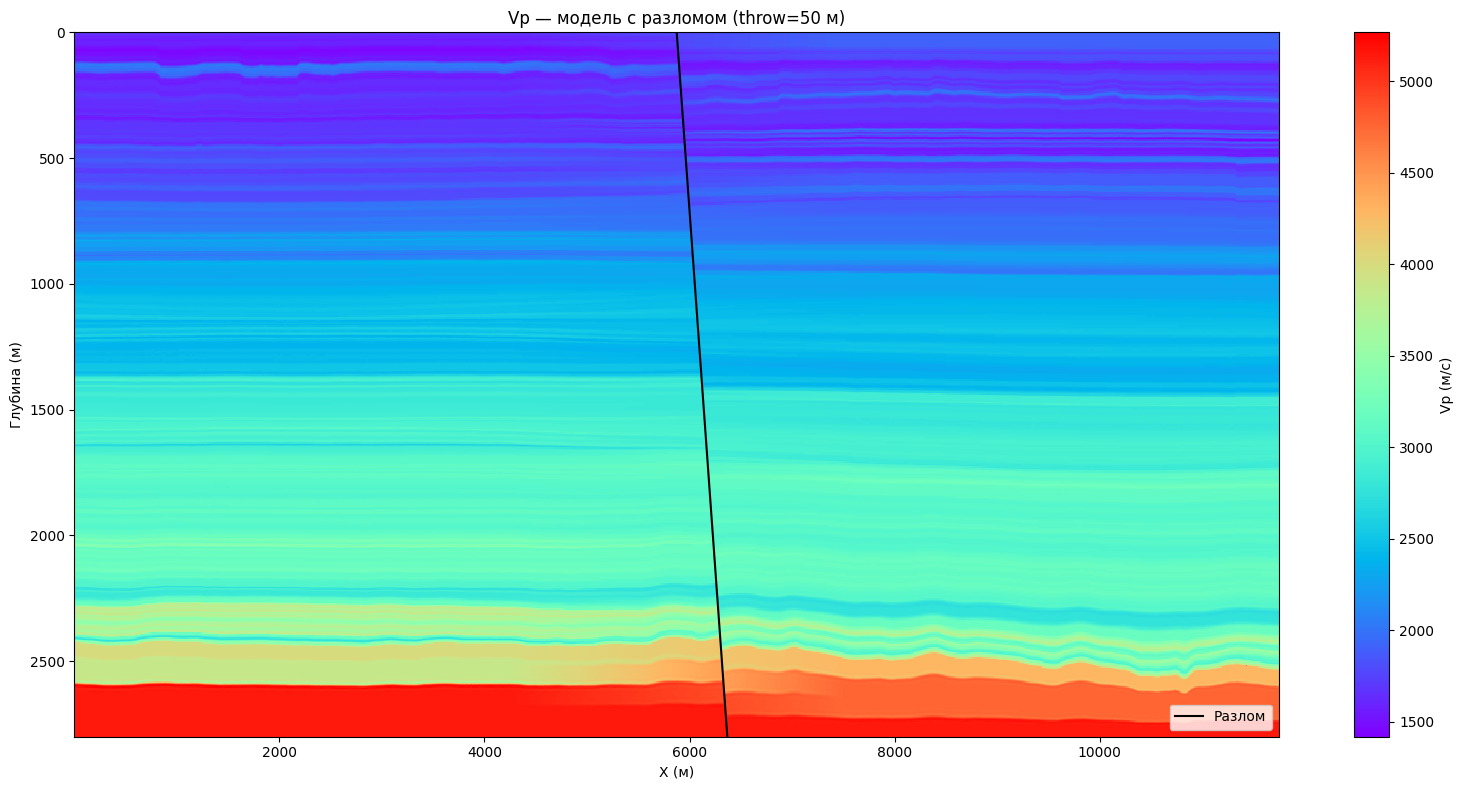

Сохранено: img/dev_3_2_Vp_a10.png


In [82]:
fig, ax = plt.subplots(figsize=(16, 8))
X, Y = np.meshgrid(x_cells, y_cells, indexing='ij')
c = ax.pcolormesh(X, Y, Vp, cmap='rainbow', shading='auto')
plt.colorbar(c, ax=ax, label='Vp (м/с)')

# Линия разлома
z_line = np.linspace(0, y_max, 100)
x_line = fault_line_x_at_depth(z_line, fault_x, fault_angle)
ax.plot(x_line, z_line, 'k-', linewidth=1.5, label='Разлом')

ax.set_xlabel('X (м)')
ax.set_ylabel('Глубина (м)')
ax.set_title(f'Vp — модель с разломом (throw={fault_throw:.0f} м)')
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_max, 0)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f'img/dev_3_2_Vp{angle_suffix}.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Сохранено: img/dev_3_2_Vp{angle_suffix}.png")

## Визуализация: Vs ##

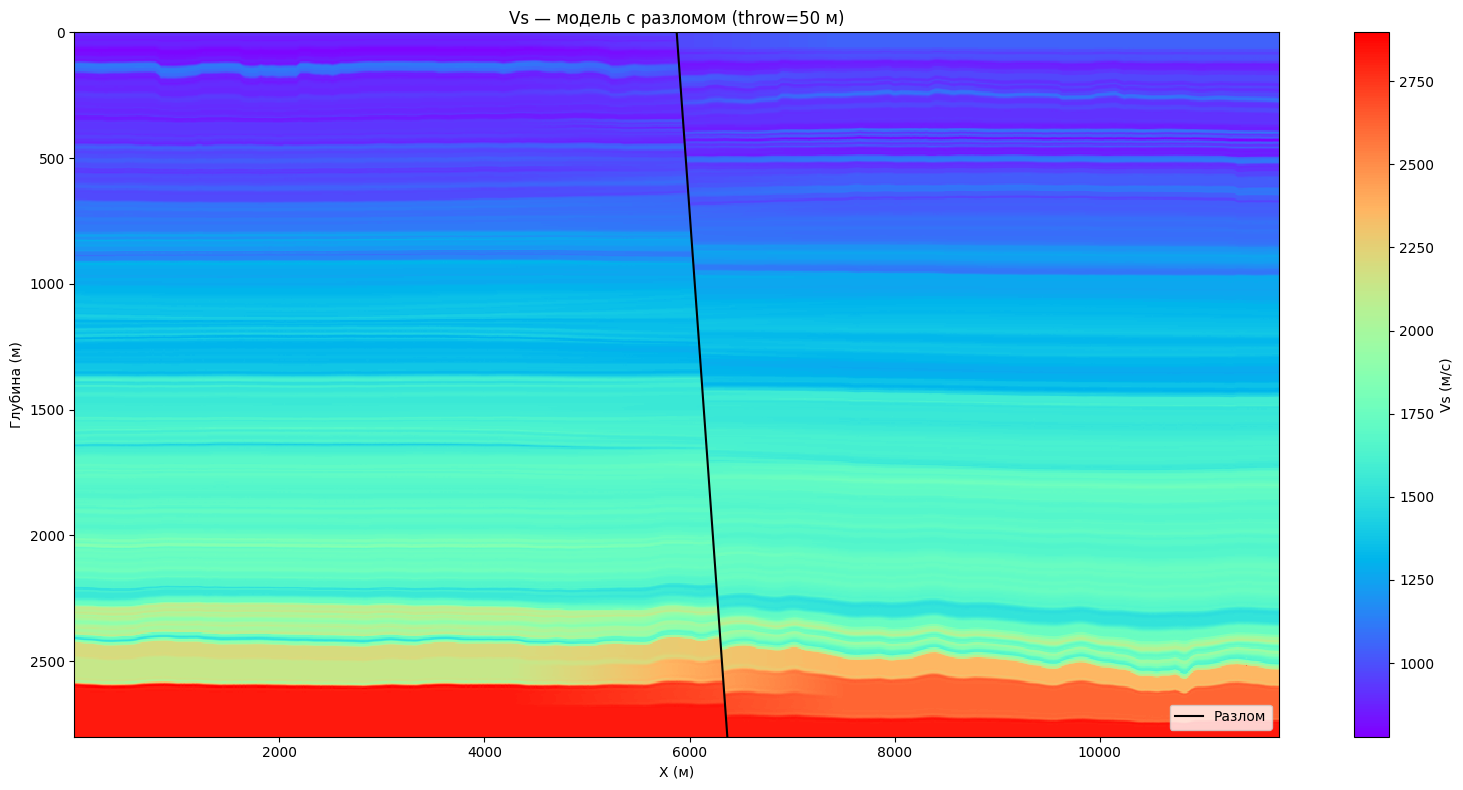

Сохранено: img/dev_3_2_Vs_a10.png


In [83]:
fig, ax = plt.subplots(figsize=(16, 8))
c = ax.pcolormesh(X, Y, Vs, cmap='rainbow', shading='auto')
plt.colorbar(c, ax=ax, label='Vs (м/с)')
ax.plot(x_line, z_line, 'k-', linewidth=1.5, label='Разлом')
ax.set_xlabel('X (м)')
ax.set_ylabel('Глубина (м)')
ax.set_title(f'Vs — модель с разломом (throw={fault_throw:.0f} м)')
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_max, 0)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f'img/dev_3_2_Vs{angle_suffix}.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Сохранено: img/dev_3_2_Vs{angle_suffix}.png")

## Визуализация: плотность ##

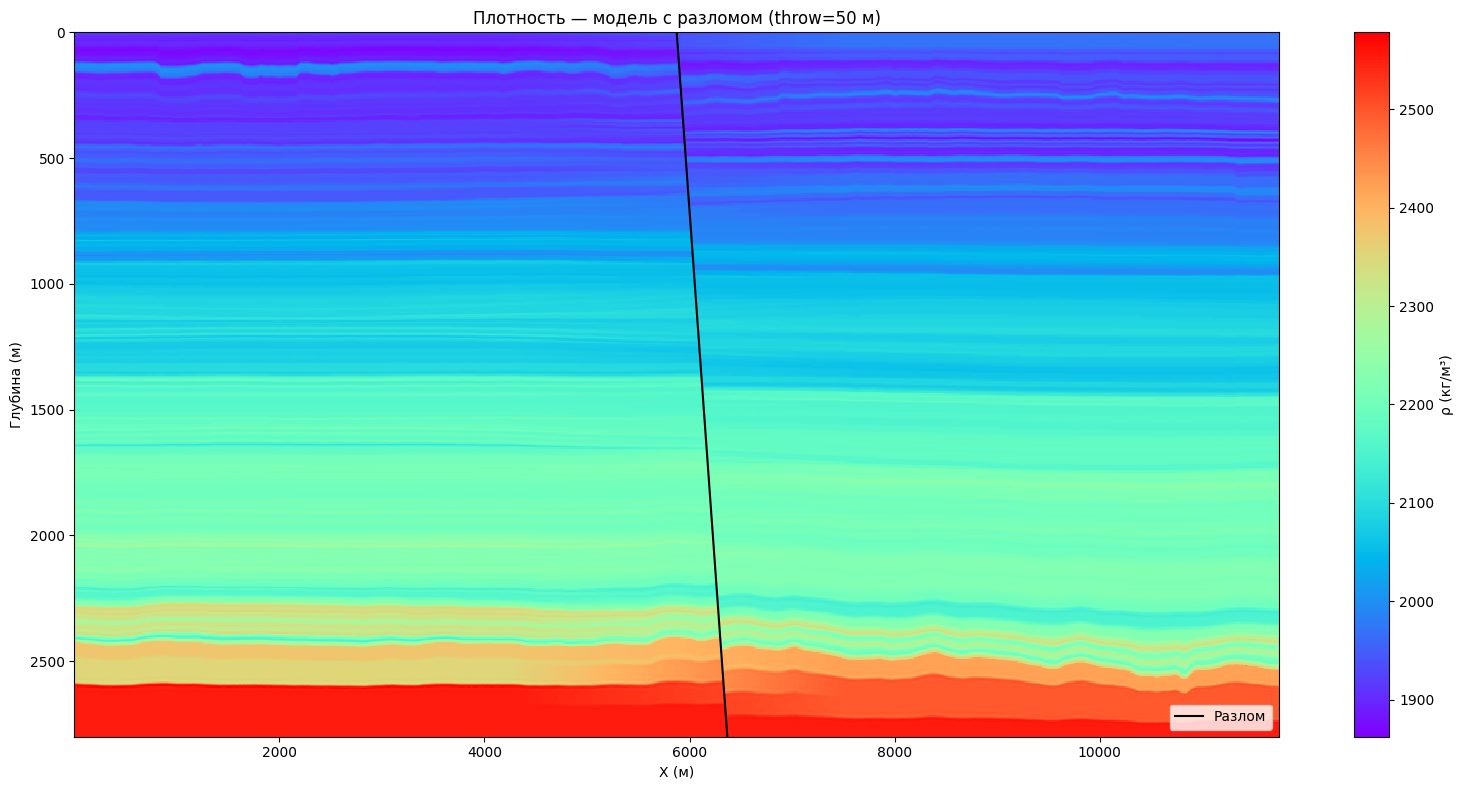

Сохранено: img/dev_3_2_rho_a10.png


In [84]:
fig, ax = plt.subplots(figsize=(16, 8))
c = ax.pcolormesh(X, Y, rho, cmap='rainbow', shading='auto')
plt.colorbar(c, ax=ax, label='ρ (кг/м³)')
ax.plot(x_line, z_line, 'k-', linewidth=1.5, label='Разлом')
ax.set_xlabel('X (м)')
ax.set_ylabel('Глубина (м)')
ax.set_title(f'Плотность — модель с разломом (throw={fault_throw:.0f} м)')
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_max, 0)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f'img/dev_3_2_rho{angle_suffix}.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Сохранено: img/dev_3_2_rho{angle_suffix}.png")

## Визуализация: детальный вид зоны разлома (Vp) ##

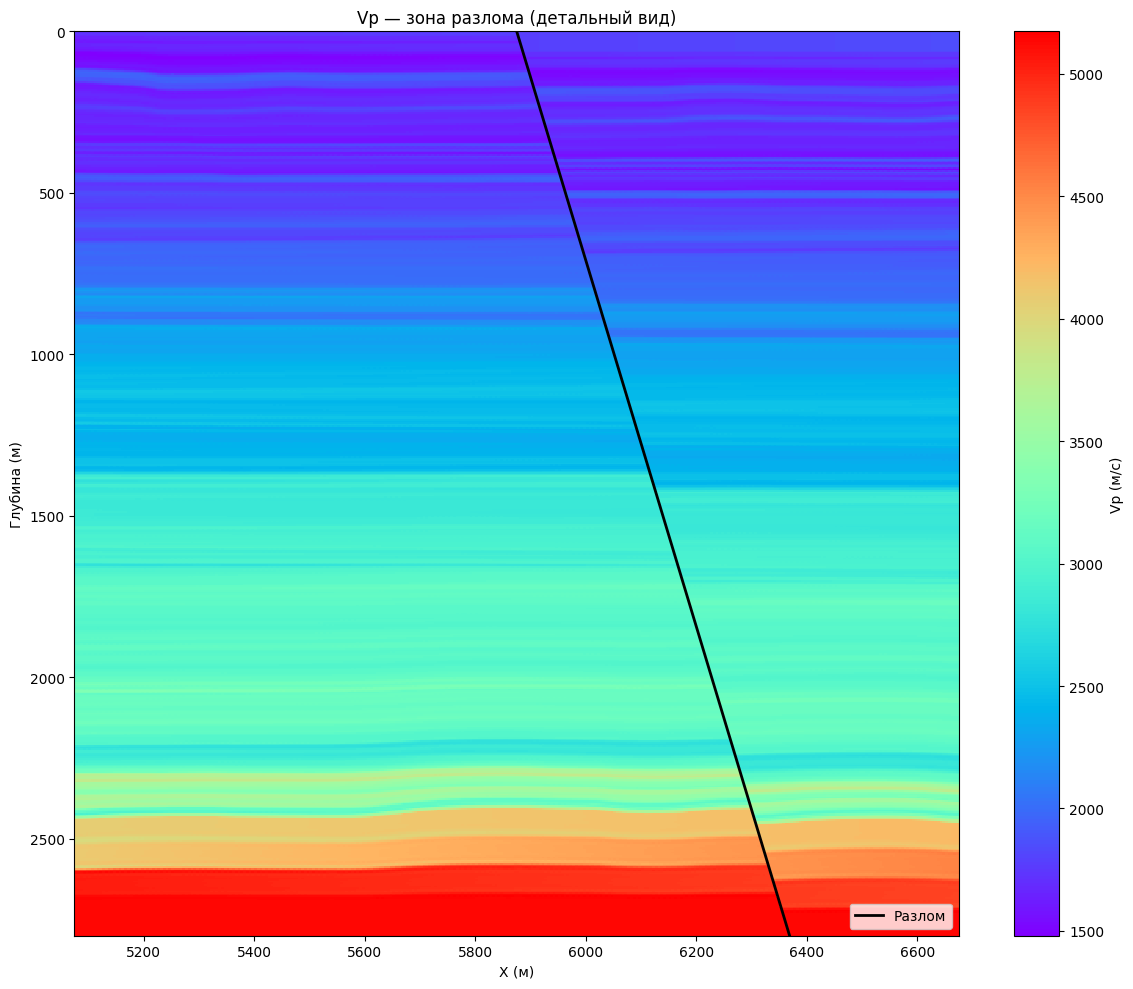

Сохранено: img/dev_3_2_Vp_detail_a10.png


In [85]:
# Окно ±800 м от центра разлома
x_detail_left = fault_x - 800
x_detail_right = fault_x + 800
ix_left = np.searchsorted(x_cells, x_detail_left)
ix_right = np.searchsorted(x_cells, x_detail_right)

fig, ax = plt.subplots(figsize=(12, 10))
X_d, Y_d = np.meshgrid(x_cells[ix_left:ix_right], y_cells, indexing='ij')
c = ax.pcolormesh(X_d, Y_d, Vp[ix_left:ix_right, :], cmap='rainbow', shading='auto')
plt.colorbar(c, ax=ax, label='Vp (м/с)')
ax.plot(x_line, z_line, 'k-', linewidth=2, label='Разлом')
ax.set_xlabel('X (м)')
ax.set_ylabel('Глубина (м)')
ax.set_title('Vp — зона разлома (детальный вид)')
ax.set_xlim(x_detail_left, x_detail_right)
ax.set_ylim(y_max, 0)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f'img/dev_3_2_Vp_detail{angle_suffix}.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Сохранено: img/dev_3_2_Vp_detail{angle_suffix}.png")

## Построение сетки координат для сохранения ##

In [86]:
X_save, Y_save = np.meshgrid(x_cells, y_cells, indexing='ij')
coords_grid = np.stack([X_save, Y_save], axis=-1)

## Сохранение результатов ##

In [87]:
np.savez_compressed(f'data/dev_3_2_fault_material{angle_suffix}.npz',
                    material_grid=material_grid,
                    coords_grid=coords_grid,
                    Vp=Vp.astype(np.float32),
                    Vs=Vs.astype(np.float32),
                    fault_x=fault_x,
                    fault_angle=fault_angle,
                    fault_throw=fault_throw,
                    model_bottom_depth=model_bottom_depth)

print(f"\nРезультаты сохранены в data/dev_3_2_fault_material{angle_suffix}.npz")
print(f"  material_grid: {material_grid.shape} (E, nu, rho)")
print(f"  coords_grid: {coords_grid.shape}")
print(f"  Vp: {Vp.shape}")
print(f"  Vs: {Vs.shape}")
print(f"  Сетка: {dx:.0f}×{dy:.0f} м")


Результаты сохранены в data/dev_3_2_fault_material_a10.npz
  material_grid: (2350, 560, 3) (E, nu, rho)
  coords_grid: (2350, 560, 2)
  Vp: (2350, 560)
  Vs: (2350, 560)
  Сетка: 5×5 м


## Выводы ##

Выполнено назначение упругих свойств материала для модели с разломом:

1. Загружен исходный материал из Главы I.7 (декартова сетка 5×5 м, E/ν/ρ)
2. Построена новая сетка с расширенной глубиной (до z_max + fault_throw)
3. Левый блок — исходный материал без изменений
4. Правый блок — тот же материал, смещённый на fault_throw вниз
   (эквивалентно чтению свойств с глубины y - fault_throw)
5. Пустоты заполнены экстраполяцией крайних строк
6. Вычислены сейсмические скорости Vp и Vs
7. Построены графики: Vp, Vs, ρ (полный вид и детальный вид зоны разлома)
8. Результаты сохранены в data/dev_3_2_fault_material.npz

Формат данных совместим с исходной Главой I.7 и может быть использован
для построения FC-модели в последующих главах.